<a href="https://colab.research.google.com/github/GWTM505/Zomato_Restro_Analysis/blob/main/Zomato_Restro_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


df_zomato = pd.read_csv(r"/zomato.csv", encoding='latin-1')
try:
    df_country = pd.read_excel('Country-Code.xlsx')
except:
    country_mapping = {1: 'India', 14: 'Australia', 30: 'Brazil', 37: 'Canada', 94: 'Indonesia', 148: 'New Zealand', 162: 'Philippines', 166: 'Qatar', 184: 'Singapore', 189: 'South Africa', 191: 'Sri Lanka', 208: 'Turkey', 214: 'UAE', 215: 'United Kingdom', 216: 'United States'}
    df_country = pd.DataFrame(list(country_mapping.items()), columns=['Country Code', 'Country'])

df = pd.merge(df_zomato, df_country, on='Country Code', how='left')
print('Successfully loaded data.')
print(f'Dataset Shape: {df.shape}')
print('\nMissing Values Per Column:')
print(df.isnull().sum())
print(f'\nDuplicate Rows in Dataset: {df.duplicated().sum()}')

Successfully loaded data.
Dataset Shape: (9551, 22)

Missing Values Per Column:
Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
Country                 0
dtype: int64

Duplicate Rows in Dataset: 0


In [27]:
df_clean = df.copy()
df_clean['Cuisines'] = df_clean['Cuisines'].fillna('Unknown')

cols_to_drop = ['Switch to order menu', 'Locality Verbose']
df_clean = df_clean.drop(columns=[col for col in cols_to_drop if col in df_clean.columns])

for col in df_clean.select_dtypes(include=['object']).columns:
    df_clean[col] = df_clean[col].astype(str).str.strip()

print('Data cleaning completed successfully.')
print(f'Cleaned Dataset Shape: {df_clean.shape}')
print(f'Dropped columns: {cols_to_drop}')
print(f'Remaining Missing Values: {df_clean.isnull().sum().sum()}')

Data cleaning completed successfully.
Cleaned Dataset Shape: (9551, 20)
Dropped columns: ['Switch to order menu', 'Locality Verbose']
Remaining Missing Values: 0


In [28]:
q1_res = df_clean['Country'].value_counts()
print('Q1: Global Footprint - Top Countries by Restaurant Count:')
print(q1_res)

Q1: Global Footprint - Top Countries by Restaurant Count:
Country
India             8652
United States      434
United Kingdom      80
Brazil              60
South Africa        60
UAE                 60
New Zealand         40
Turkey              34
Australia           24
Phillipines         22
Indonesia           21
Qatar               20
Singapore           20
Sri Lanka           20
Canada               4
Name: count, dtype: int64


In [29]:
q2_res = df_clean.groupby('Has Table booking')['Aggregate rating'].mean()
print('Q2: Average Rating by Table Booking:')
print(q2_res)

Q2: Average Rating by Table Booking:
Has Table booking
No     2.559359
Yes    3.441969
Name: Aggregate rating, dtype: float64


In [30]:
q3_res = df_clean.groupby(['Country', 'Currency'])['Average Cost for two'].mean().sort_values(ascending=False)
print('Q3: Average Cost for Two by Country:')
print(q3_res)

Q3: Average Cost for Two by Country:
Country         Currency              
Indonesia       Indonesian Rupiah(IDR)    281190.476190
Sri Lanka       Sri Lankan Rupee(LKR)       2375.000000
Phillipines     Botswana Pula(P)            1606.818182
India           Indian Rupees(Rs.)           623.370319
South Africa    Rand(R)                      419.733333
Qatar           Qatari Rial(QR)              223.750000
UAE             Emirati Diram(AED)           166.416667
Singapore       Dollar($)                    155.750000
Brazil          Brazilian Real(R$)           134.666667
Turkey          Turkish Lira(TL)              84.852941
New Zealand     NewZealand($)                 69.750000
United Kingdom  Pounds(£)                    47.812500
Canada          Dollar($)                     36.250000
United States   Dollar($)                     26.152074
Australia       Dollar($)                     24.083333
Name: Average Cost for two, dtype: float64


In [31]:
cuisines_series = df_clean['Cuisines'].str.split(',').explode().str.strip()
q4_res = cuisines_series.value_counts().head(10)
print('Q4: Top 10 Most Common Cuisines Served Globally:')
print(q4_res)

Q4: Top 10 Most Common Cuisines Served Globally:
Cuisines
North Indian    3960
Chinese         2735
Fast Food       1986
Mughlai          995
Italian          764
Bakery           745
Continental      736
Cafe             703
Desserts         653
South Indian     636
Name: count, dtype: int64


In [32]:
q5_corr = df_clean['Aggregate rating'].corr(df_clean['Votes'])

def get_rating_bin(val):
    if val == 0: return '0.0 (Not Rated)'
    elif val < 2: return '0.1 - 1.9'
    elif val < 3: return '2.0 - 2.9'
    elif val < 4: return '3.0 - 3.9'
    else: return '4.0 - 5.0'
df_clean['Rating Bin'] = df_clean['Aggregate rating'].apply(get_rating_bin)
q5_bin_votes = df_clean.groupby('Rating Bin')['Votes'].mean()

print(f'Q5: Correlation between Rating and Votes: {q5_corr:.4f}')
print('\nAverage Votes by Rating Category:')
print(q5_bin_votes)

Q5: Correlation between Rating and Votes: 0.3137

Average Votes by Rating Category:
Rating Bin
0.0 (Not Rated)      0.870112
0.1 - 1.9          178.000000
2.0 - 2.9           45.600000
3.0 - 3.9          133.567756
4.0 - 5.0          592.723188
Name: Votes, dtype: float64


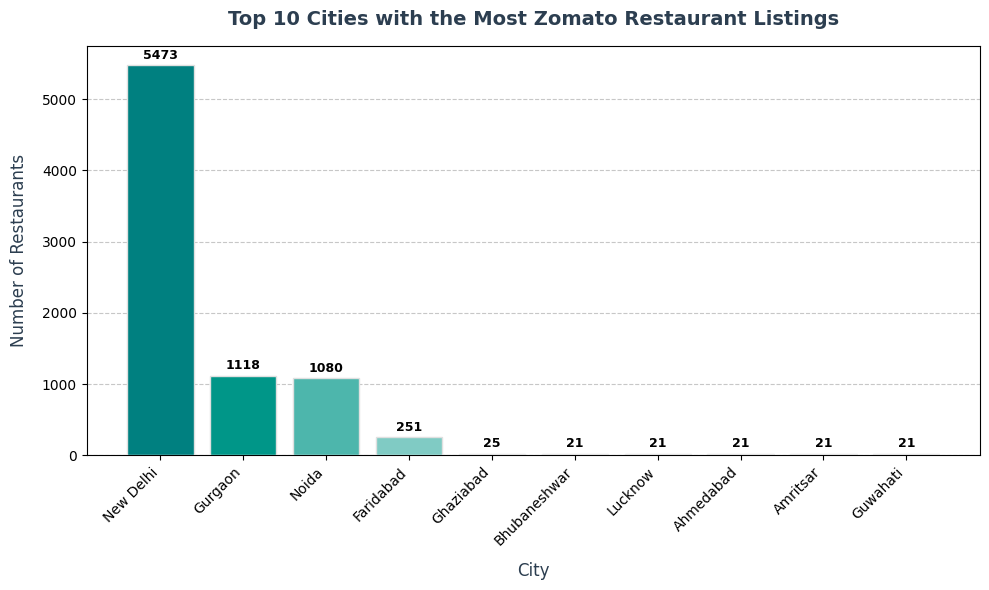

In [33]:
plt.figure(figsize=(10, 6))
top_cities = df_clean['City'].value_counts().head(10)
colors = ['#008080', '#009688', '#4db6ac', '#80cbc4', '#b2dfdb', '#a3e4d7', '#76d7c4', '#48c9b0', '#1abc9c', '#16a085']
bars = plt.bar(top_cities.index, top_cities.values, color=colors, edgecolor='#e0e0e0', zorder=3)
plt.title('Top 10 Cities with the Most Zomato Restaurant Listings', fontsize=14, fontweight='bold', pad=15, color='#2c3e50')
plt.xlabel('City', fontsize=12, labelpad=10, color='#2c3e50')
plt.ylabel('Number of Restaurants', fontsize=12, labelpad=10, color='#2c3e50')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7, zorder=0)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 50, f'{yval}', ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

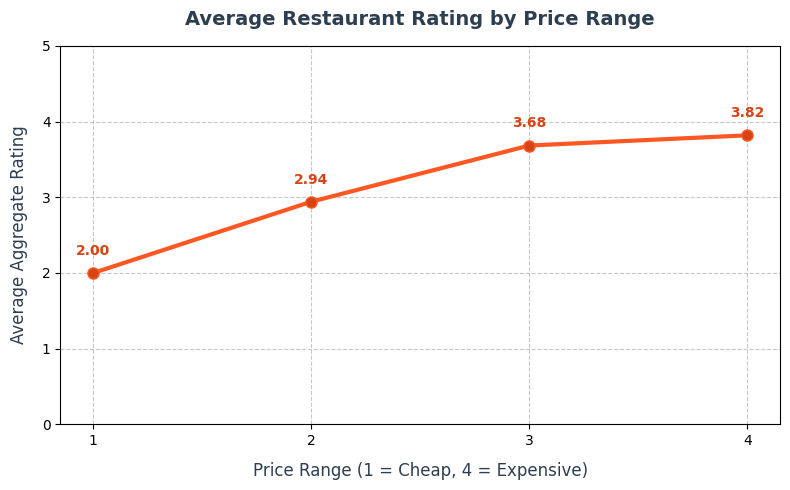

In [34]:
plt.figure(figsize=(8, 5))
avg_rating_price = df_clean.groupby('Price range')['Aggregate rating'].mean()
plt.plot(avg_rating_price.index, avg_rating_price.values, marker='o', linewidth=3, markersize=8, color='#ff5722', markerfacecolor='#d84315', zorder=3)
plt.title('Average Restaurant Rating by Price Range', fontsize=14, fontweight='bold', pad=15, color='#2c3e50')
plt.xlabel('Price Range (1 = Cheap, 4 = Expensive)', fontsize=12, labelpad=10, color='#2c3e50')
plt.ylabel('Average Aggregate Rating', fontsize=12, labelpad=10, color='#2c3e50')
plt.xticks(avg_rating_price.index)
plt.ylim(0, 5)
plt.grid(True, linestyle='--', alpha=0.7, zorder=0)
for x, y in zip(avg_rating_price.index, avg_rating_price.values):
    plt.text(x, y + 0.2, f'{y:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold', color='#d84315')
plt.tight_layout()
plt.show()

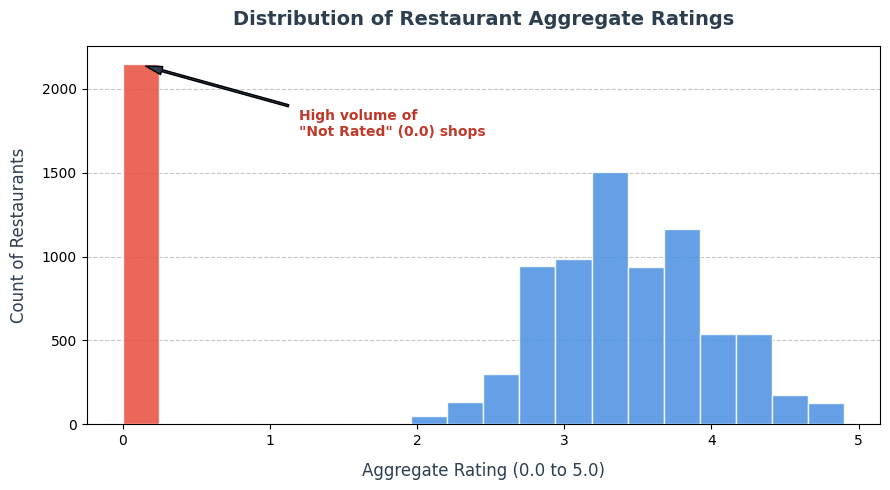

In [35]:
plt.figure(figsize=(9, 5))
counts, bins, patches = plt.hist(df_clean['Aggregate rating'], bins=20, color='#4a90e2', edgecolor='white', alpha=0.85, zorder=3)
patches[0].set_facecolor('#e74c3c')
plt.title('Distribution of Restaurant Aggregate Ratings', fontsize=14, fontweight='bold', pad=15, color='#2c3e50')
plt.xlabel('Aggregate Rating (0.0 to 5.0)', fontsize=12, labelpad=10, color='#2c3e50')
plt.ylabel('Count of Restaurants', fontsize=12, labelpad=10, color='#2c3e50')
plt.grid(axis='y', linestyle='--', alpha=0.7, zorder=0)
plt.annotate('High volume of\n"Not Rated" (0.0) shops', xy=(0.1, counts[0]), xytext=(1.2, counts[0]*0.8),
arrowprops=dict(facecolor='#2c3e50', shrink=0.05, width=1.5, headwidth=6),
fontsize=10, fontweight='bold', color='#c0392b')
plt.tight_layout()
plt.show()

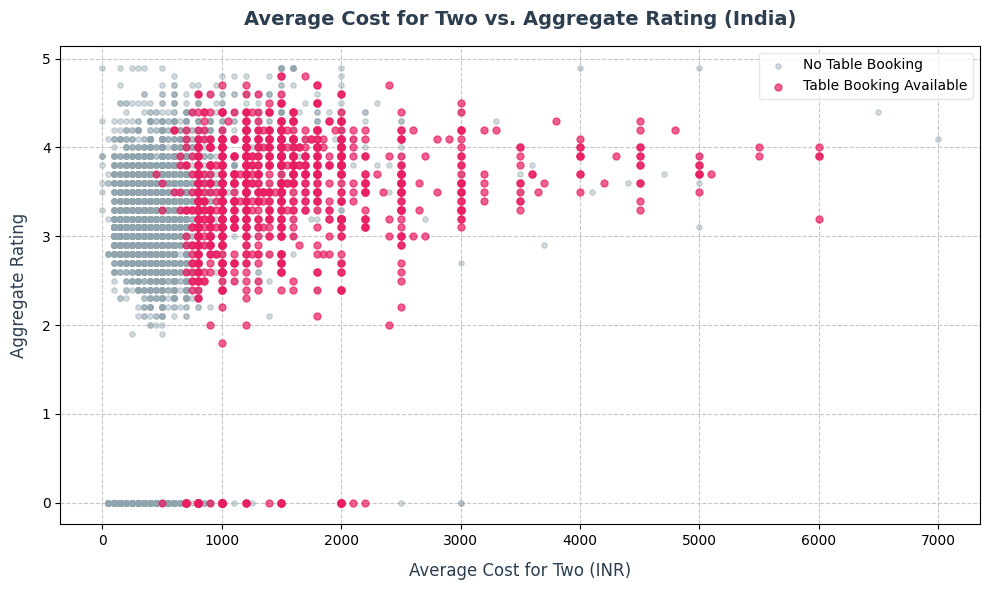

In [36]:
plt.figure(figsize=(10, 6))
df_india = df_clean[(df_clean['Country'] == 'India') & (df_clean['Average Cost for two'] < 8000)]
yes_book = df_india[df_india['Has Table booking'] == 'Yes']
no_book = df_india[df_india['Has Table booking'] == 'No']
plt.scatter(no_book['Average Cost for two'], no_book['Aggregate rating'], alpha=0.4, label='No Table Booking', color='#90a4ae', s=15, zorder=3)
plt.scatter(yes_book['Average Cost for two'], yes_book['Aggregate rating'], alpha=0.7, label='Table Booking Available', color='#e91e63', s=25, zorder=4)
plt.title('Average Cost for Two vs. Aggregate Rating (India)', fontsize=14, fontweight='bold', pad=15, color='#2c3e50')
plt.xlabel('Average Cost for Two (INR)', fontsize=12, labelpad=10, color='#2c3e50')
plt.ylabel('Aggregate Rating', fontsize=12, labelpad=10, color='#2c3e50')
plt.legend(frameon=True, facecolor='#ffffff', edgecolor='#e0e0e0', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7, zorder=0)
plt.tight_layout()
plt.show()

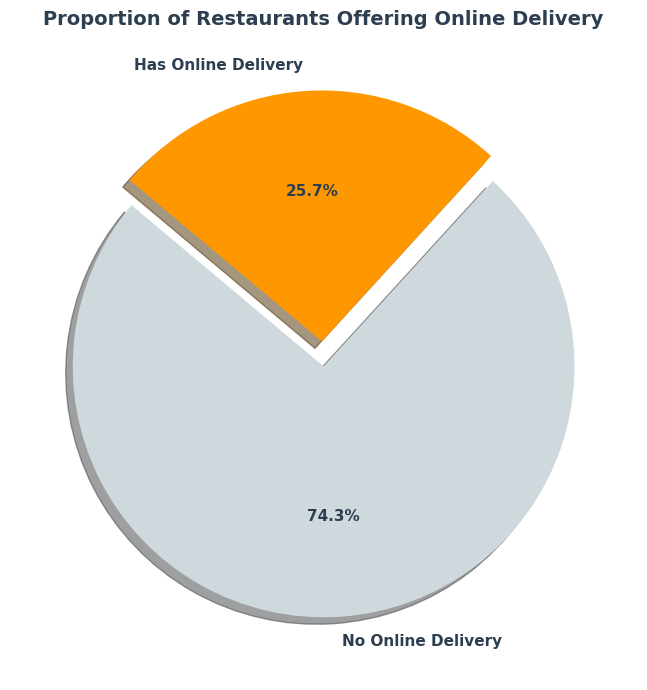

In [37]:
plt.figure(figsize=(7, 7))
delivery_counts = df_clean['Has Online delivery'].value_counts()
colors_pie = ['#cfd8dc', '#ff9800']
plt.pie(delivery_counts.values, labels=['No Online Delivery', 'Has Online Delivery'],
        autopct='%1.1f%%', startangle=140, colors=colors_pie,
        explode=(0, 0.1), shadow=True, textprops={'fontsize': 11, 'fontweight': 'bold', 'color': '#2c3e50'})
plt.title('Proportion of Restaurants Offering Online Delivery', fontsize=14, fontweight='bold', pad=20, color='#2c3e50')
plt.tight_layout()
plt.show()

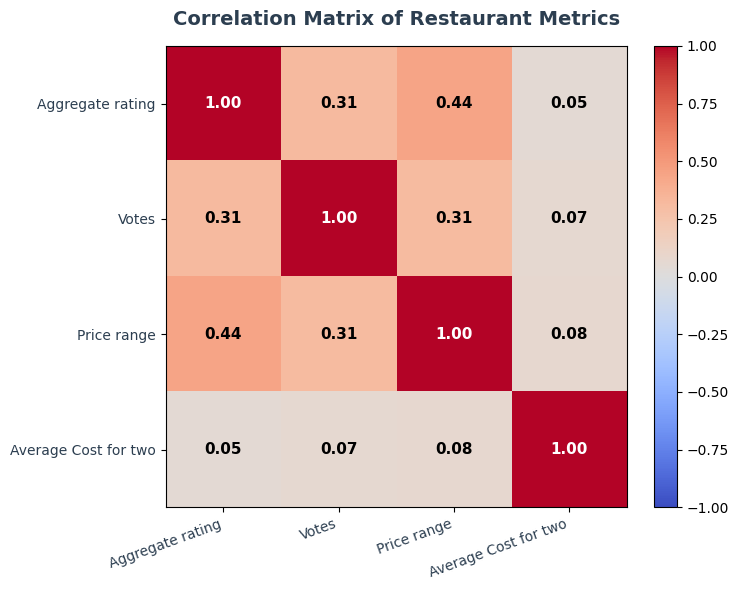

In [38]:
plt.figure(figsize=(8, 6))
corr_cols = ['Aggregate rating', 'Votes', 'Price range', 'Average Cost for two']
corr_mat = df_clean[corr_cols].corr()
im = plt.imshow(corr_mat, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.title('Correlation Matrix of Restaurant Metrics', fontsize=14, fontweight='bold', pad=15, color='#2c3e50')
plt.xticks(range(len(corr_cols)), corr_cols, rotation=20, ha='right', fontsize=10, color='#2c3e50')
plt.yticks(range(len(corr_cols)), corr_cols, fontsize=10, color='#2c3e50')
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        val = corr_mat.iloc[i, j]
        color = 'white' if abs(val) > 0.5 else 'black'
        plt.text(j, i, f'{val:.2f}', ha='center', va='center', color=color, fontweight='bold', fontsize=11)
plt.grid(False)
plt.tight_layout()
plt.show()

## Insights Report

Here are 5 key insights derived from the Zomato restaurant data:

1.  **Geographical Dominance**: India has an overwhelming presence in the dataset, with a significantly higher number of listed restaurants compared to all other countries combined. This suggests Zomato's strongest market penetration is in India.
2.  **Table Booking and Ratings**: Restaurants that offer table booking services tend to have a noticeably higher average aggregate rating than those that do not. This could imply a correlation between service quality (or perhaps a restaurant's investment in customer convenience) and customer satisfaction reflected in ratings.
3.  **Popular Cuisines**: 'North Indian', 'Chinese', and 'Fast Food' are the top three most commonly served cuisines globally according to this dataset. This highlights popular culinary preferences across Zomato's operating regions.
4.  **Rating Disparity**: A substantial portion of restaurants in the dataset have an 'Aggregate rating' of 0.0, which indicates a 'Not Rated' status rather than a poor rating. This segment represents a significant number of establishments whose performance is not yet captured by user reviews.
5.  **Online Delivery Landscape**: The majority of restaurants in the dataset do not offer online delivery. This suggests a potential area for growth or indicates that a large segment of Zomato-listed establishments primarily cater to dine-in or pick-up customers.

### Most Surprising Finding:

The most surprising finding was the significant number of restaurants exhibiting an 'Aggregate rating' of 0.0. This initially appeared to indicate extremely poor performance, but further investigation revealed it signifies a 'Not Rated' status. This distinction is crucial for accurate data interpretation, as it points to a large segment of restaurants whose customer satisfaction is not yet captured by the rating system, rather than universally negative experiences.